# MobileNetV2 + VGG16 Early Fusion — NTW Dataset — Participant Level

This corrected notebook trains and evaluates both:

1. Concatenation early fusion
2. Attention early fusion

Training schedule for each fusion model:

- Frozen-backbone warm-up: 10 epochs
- Partial fine-tuning: 25 epochs
- Total per fusion model: 35 epochs
- Total for both fusion models: 70 model-training epochs

Participant-level improvements:

- Participant-disjoint 70/15/15 split
- Participant-balanced class weights during training
- Validation-derived participant decision threshold
- Participant-level probability averaging
- Accuracy, precision, recall, specificity, F1-score and ROC-AUC
- Keras models, summaries, parameters, histories and graphs
- Confusion matrices, ROC curves, reports, NPZ and prediction CSV files
- High-resolution, automatically filtered fusion Grad-CAM figures

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:

import json
import random
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_preprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# CHANGE ONLY THESE THREE PATHS
ZIP_PATH = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_dataset_here/Parkinson_dataset_2.zip"
UNZIP_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_dataset_unzip_here"
SAVE_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

WARMUP_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
EPOCHS_PER_FUSION_MODEL = WARMUP_EPOCHS + FINE_TUNE_EPOCHS
TOTAL_EPOCHS_FOR_BOTH_FUSIONS = EPOCHS_PER_FUSION_MODEL * 2
VGG_FINE_TUNE_LAST = 8
MOBILENET_FINE_TUNE_LAST = 25

FUSION_METHODS = ["concatenation", "attention"]

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
print("Results folder:", SAVE_DIR)
print("Frozen warm-up epochs:", WARMUP_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)
print("Epochs per fusion model:", EPOCHS_PER_FUSION_MODEL)
print("Total epochs for both fusion models:", TOTAL_EPOCHS_FOR_BOTH_FUSIONS)


Results folder: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results
Frozen warm-up epochs: 10
Fine-tuning epochs: 25
Epochs per fusion model: 35
Total epochs for both fusion models: 70


In [4]:
# UNZIP DATASET AND BUILD METADATA
if not Path(ZIP_PATH).exists():
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if Path(UNZIP_DIR).exists():
    shutil.rmtree(UNZIP_DIR)
Path(UNZIP_DIR).mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(UNZIP_DIR)

def find_dataset_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if (candidate / "healthy_control").is_dir() and (candidate / "parkinson").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find a folder containing both healthy_control and parkinson."
    )

DATASET_ROOT = find_dataset_root(UNZIP_DIR)
print("Dataset root:", DATASET_ROOT)

valid_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
class_mapping = {"healthy_control": 0, "parkinson": 1}

records = []

for class_name, label in class_mapping.items():
    for image_path in (DATASET_ROOT / class_name).rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in valid_extensions:
            records.append(
                {
                    "filepath": str(image_path),
                    "label": label,
                    "class_name": class_name,
                    "patient_id": image_path.parent.name,
                    "source_dataset": image_path.parent.parent.name,
                }
            )

df = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)

if df.empty:
    raise ValueError("No images were found.")

print("Total images:", len(df))
print("\nImages by class:")
print(df["class_name"].value_counts())

print("\nParticipants by class:")
print(df.groupby("class_name")["patient_id"].nunique())

print("\nImages by source dataset:")
print(df["source_dataset"].value_counts())

print("\nImages per participant:")
display(df.groupby("patient_id").size().describe().to_frame("images_per_participant"))

df.to_csv(Path(SAVE_DIR) / "NTW_complete_metadata.csv", index=False)

Dataset root: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_dataset_unzip_here/sagittal_images
Total images: 3320

Images by class:
class_name
parkinson          1880
healthy_control    1440
Name: count, dtype: int64

Participants by class:
class_name
healthy_control    36
parkinson          47
Name: patient_id, dtype: int64

Images by source dataset:
source_dataset
NEUROCON    1720
Tao_Wu      1600
Name: count, dtype: int64

Images per participant:


,images_per_participant
count,83.0
mean,40.0
std,0.0
min,40.0
25%,40.0
50%,40.0
75%,40.0
max,40.0


In [5]:
# PARTICIPANT-DISJOINT 70/15/15 SPLIT
participant_table = (
    df.groupby("patient_id", as_index=False)
    .agg(
        label=("label", "first"),
        class_name=("class_name", "first"),
        source_dataset=("source_dataset", "first"),
        number_of_images=("filepath", "size"),
    )
)

train_participants, temporary_participants = train_test_split(
    participant_table,
    test_size=0.30,
    random_state=SEED,
    stratify=participant_table["label"],
)

validation_participants, test_participants = train_test_split(
    temporary_participants,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_participants["label"],
)

train_ids = set(train_participants["patient_id"])
validation_ids = set(validation_participants["patient_id"])
test_ids = set(test_participants["patient_id"])

assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

train_df = df[df["patient_id"].isin(train_ids)].copy()
validation_df = df[df["patient_id"].isin(validation_ids)].copy()
test_df = df[df["patient_id"].isin(test_ids)].copy()

for split_name, participant_frame, image_frame in [
    ("Training", train_participants, train_df),
    ("Validation", validation_participants, validation_df),
    ("Testing", test_participants, test_df),
]:
    print(
        f"\n{split_name}: {len(participant_frame)} participants, "
        f"{len(image_frame)} images"
    )
    print(participant_frame["class_name"].value_counts())

train_participants.to_csv(
    Path(SAVE_DIR) / "participant_train_split.csv",
    index=False,
)
validation_participants.to_csv(
    Path(SAVE_DIR) / "participant_validation_split.csv",
    index=False,
)
test_participants.to_csv(
    Path(SAVE_DIR) / "participant_test_split.csv",
    index=False,
)

# PARTICIPANT-BALANCED CLASS WEIGHTS
participant_class_counts = (
    train_participants["label"]
    .value_counts()
    .sort_index()
)

number_of_training_participants = len(
    train_participants
)
number_of_classes = len(
    participant_class_counts
)

CLASS_WEIGHTS = {
    int(label): float(
        number_of_training_participants
        / (
            number_of_classes
            * count
        )
    )
    for label, count
    in participant_class_counts.items()
}

print("\nParticipant-balanced class weights:")
print(CLASS_WEIGHTS)



Training: 58 participants, 2320 images
class_name
parkinson          33
healthy_control    25
Name: count, dtype: int64

Validation: 12 participants, 480 images
class_name
parkinson          7
healthy_control    5
Name: count, dtype: int64

Testing: 13 participants, 520 images
class_name
parkinson          7
healthy_control    6
Name: count, dtype: int64

Participant-balanced class weights:
{0: 1.16, 1: 0.8787878787878788}


In [6]:
# DUAL-INPUT TF.DATA PIPELINE
AUTOTUNE = tf.data.AUTOTUNE

augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.04, fill_mode="nearest", seed=SEED),
        layers.RandomZoom(0.10, fill_mode="nearest", seed=SEED),
        layers.RandomTranslation(
            0.05,
            0.05,
            fill_mode="nearest",
            seed=SEED,
        ),
    ],
    name="augmentation",
)

def decode_dual_input(path, label, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    if training:
        image = augmentation(image, training=True)

    return {
        "vgg_input": vgg_preprocess(tf.identity(image)),
        "mobile_input": mobile_preprocess(tf.identity(image)),
    }, tf.cast(label, tf.float32)

def make_dataset(frame, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            frame["filepath"].astype(str).values,
            frame["label"].astype("float32").values,
        )
    )

    if training:
        dataset = dataset.shuffle(
            len(frame),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        lambda path, label: decode_dual_input(path, label, training),
        num_parallel_calls=AUTOTUNE,
    )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("TensorFlow datasets created.")

TensorFlow datasets created.


In [7]:
# MODEL AND OUTPUT HELPERS
def create_result_folders(run_folder):
    folder_names = [
        "models",
        "summaries",
        "parameters",
        "histories",
        "graphs",
        "metrics",
        "classification_reports",
        "confusion_matrices",
        "roc_curves",
        "npz",
        "predictions",
        "gradcam",
    ]

    folders = {}
    for folder_name in folder_names:
        folders[folder_name] = Path(run_folder) / folder_name
        folders[folder_name].mkdir(parents=True, exist_ok=True)

    return folders

def build_model(fusion_type):
    vgg_input = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="vgg_input",
    )
    mobile_input = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="mobile_input",
    )

    vgg_backbone = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    mobile_backbone = MobileNetV2(
                weights="imagenet",
                include_top=False,
                input_shape=(*IMG_SIZE, 3),
            )

    vgg_backbone.trainable = False
    mobile_backbone.trainable = False

    vgg_feature_map = vgg_backbone(vgg_input, training=False)
    mobile_feature_map = mobile_backbone(mobile_input, training=False)

    vgg_vector = layers.GlobalAveragePooling2D(
        name="vgg_gap"
    )(vgg_feature_map)
    mobile_vector = layers.GlobalAveragePooling2D(
        name="mobile_gap"
    )(mobile_feature_map)

    vgg_vector = layers.Dense(
        256,
        activation="relu",
        name="vgg_projection",
    )(vgg_vector)
    mobile_vector = layers.Dense(
        256,
        activation="relu",
        name="mobile_projection",
    )(mobile_vector)

    if fusion_type == "concatenation":
        fused_vector = layers.Concatenate(
            name="fusion_concat"
        )([vgg_vector, mobile_vector])
    else:
        vgg_token = layers.Reshape(
            (1, 256),
            name="vgg_token",
        )(vgg_vector)
        mobile_token = layers.Reshape(
            (1, 256),
            name="mobile_token",
        )(mobile_vector)

        feature_stack = layers.Concatenate(
            axis=1,
            name="feature_stack",
        )([vgg_token, mobile_token])

        attention_scores = layers.Dense(
            1,
            name="attention_score",
        )(feature_stack)

        attention_weights = layers.Softmax(
            axis=1,
            name="attention_weights",
        )(attention_scores)

        weighted_features = layers.Multiply(
            name="weighted_features",
        )([feature_stack, attention_weights])

        fused_vector = layers.Flatten(
            name="weighted_flatten",
        )(weighted_features)

    x = layers.Dense(
        256,
        activation="relu",
        name="fusion_dense",
    )(fused_vector)
    x = layers.Dropout(
        0.50,
        name="fusion_dropout",
    )(x)
    output = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction",
    )(x)

    model = keras.Model(
        inputs={
            "vgg_input": vgg_input,
            "mobile_input": mobile_input,
        },
        outputs=output,
        name=f"MobileNetV2_VGG16_{fusion_type}_NTW",
    )
    return model, vgg_backbone, mobile_backbone

def compile_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

def locate_backbones(model):
    vgg_backbone = None
    mobile_backbone = None

    for layer in model.layers:
        if isinstance(layer, keras.Model):
            if layer.name.startswith("vgg16"):
                vgg_backbone = layer
            elif layer.name.startswith("mobilenetv2"):
                mobile_backbone = layer

    if vgg_backbone is None or mobile_backbone is None:
        raise ValueError("Could not locate both backbones.")

    return vgg_backbone, mobile_backbone

def save_summary_and_parameters(model, folders, file_prefix):
    summary_lines = []
    model.summary(print_fn=summary_lines.append)

    (
        folders["summaries"]
        / f"{file_prefix}_model_summary.txt"
    ).write_text(
        "\n".join(summary_lines),
        encoding="utf-8",
    )

    trainable_count = sum(
        int(tf.keras.backend.count_params(weight))
        for weight in model.trainable_weights
    )
    non_trainable_count = sum(
        int(tf.keras.backend.count_params(weight))
        for weight in model.non_trainable_weights
    )

    parameter_frame = pd.DataFrame(
        [
            {
                "model": model.name,
                "total_parameters": (
                    trainable_count + non_trainable_count
                ),
                "trainable_parameters": trainable_count,
                "non_trainable_parameters": non_trainable_count,
            }
        ]
    )

    display(parameter_frame)
    parameter_frame.to_csv(
        folders["parameters"]
        / f"{file_prefix}_parameter_counts.csv",
        index=False,
    )

def merge_histories(*history_objects):
    merged = {}

    for history_object in history_objects:
        for metric_name, values in history_object.history.items():
            merged.setdefault(metric_name, [])
            merged[metric_name].extend(
                [float(value) for value in values]
            )

    return merged

def save_history_and_graphs(
    history,
    folders,
    file_prefix,
    title_prefix,
):
    pd.DataFrame(history).to_csv(
        folders["histories"]
        / f"{file_prefix}_history.csv",
        index=False,
    )

    with open(
        folders["histories"]
        / f"{file_prefix}_history.json",
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(history, output_file, indent=2)

    epochs = np.arange(1, len(history["loss"]) + 1)

    for metric_name, y_label, file_suffix in [
        ("accuracy", "Accuracy", "accuracy"),
        ("loss", "Binary Cross-Entropy Loss", "loss"),
        ("auc", "ROC-AUC", "auc"),
    ]:
        plt.figure(figsize=(9, 6))
        plt.plot(
            epochs,
            history[metric_name],
            linewidth=2,
            label=f"Training {y_label}",
        )
        plt.plot(
            epochs,
            history[f"val_{metric_name}"],
            linewidth=2,
            label=f"Validation {y_label}",
        )
        plt.axvline(
            WARMUP_EPOCHS,
            linestyle="--",
            label="Fine-Tuning Start",
        )
        plt.title(
            f"{title_prefix} {y_label}",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Epoch")
        plt.ylabel(y_label)

        if metric_name in {"accuracy", "auc"}:
            plt.ylim(0, 1.02)

        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            folders["graphs"]
            / f"{file_prefix}_{file_suffix}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [8]:
# TRAIN ONE FUSION METHOD
def train_fusion_method(fusion_type):
    run_folder = Path(SAVE_DIR) / fusion_type
    folders = create_result_folders(run_folder)
    file_prefix = f"MobileNetV2_VGG16_{fusion_type}_NTW"

    model, vgg_backbone, mobile_backbone = build_model(
        fusion_type
    )

    # Stage 1: frozen warm-up
    compile_model(model, 1e-4)

    warmup_path = (
        folders["models"]
        / f"{file_prefix}_warmup_best.keras"
    )

    warmup_callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(warmup_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    warmup_history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=WARMUP_EPOCHS,
        callbacks=warmup_callbacks,
        class_weight=CLASS_WEIGHTS,
        verbose=1,
    )

    model = keras.models.load_model(warmup_path)
    vgg_backbone, mobile_backbone = locate_backbones(model)

    # Stage 2: partial fine-tuning
    vgg_backbone.trainable = True
    mobile_backbone.trainable = True

    for layer in vgg_backbone.layers[:-VGG_FINE_TUNE_LAST]:
        layer.trainable = False
    for layer in vgg_backbone.layers[-VGG_FINE_TUNE_LAST:]:
        layer.trainable = True

    for layer in mobile_backbone.layers[:-MOBILENET_FINE_TUNE_LAST]:
        layer.trainable = False
    for layer in mobile_backbone.layers[-MOBILENET_FINE_TUNE_LAST:]:
        layer.trainable = True

    compile_model(model, 5e-6)

    save_summary_and_parameters(
        model,
        folders,
        file_prefix,
    )

    best_path = (
        folders["models"]
        / f"{file_prefix}_best.keras"
    )

    fine_tune_callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(best_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            str(
                folders["histories"]
                / f"{file_prefix}_training_log.csv"
            )
        ),
    ]

    fine_tune_history = model.fit(
        train_ds,
        validation_data=validation_ds,
        initial_epoch=WARMUP_EPOCHS,
        epochs=WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
        callbacks=fine_tune_callbacks,
        class_weight=CLASS_WEIGHTS,
        verbose=1,
    )

    complete_history = merge_histories(
        warmup_history,
        fine_tune_history,
    )

    save_history_and_graphs(
        complete_history,
        folders,
        file_prefix,
        (
            "MobileNetV2 + VGG16 NTW Dataset — "
            f"{fusion_type.title()}"
        ),
    )

    best_model = keras.models.load_model(best_path)
    return best_model, folders, file_prefix

In [9]:

# ============================================================
# METRICS, REPORTS, CONFUSION MATRIX, ROC, NPZ AND GRAD-CAM
# ============================================================

def save_evaluation_outputs(
    y_true,
    y_score,
    y_pred,
    decision_threshold,
    gradcam_source,
    model,
    fusion_type,
    folders,
    file_prefix,
):
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = matrix.ravel()

    metrics = {
        "Model": file_prefix,
        "Evaluation_Level": "Participant-Level",
        "Fusion_Type": fusion_type,
        "Decision_Threshold": float(decision_threshold),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Specificity": (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        ),
        "F1_Score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_score,
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Evaluation_Samples": int(len(y_true)),
    }

    metrics_frame = pd.DataFrame([metrics])
    display(metrics_frame)

    metrics_frame.to_csv(
        folders["metrics"]
        / f"{file_prefix}_participant_metrics.csv",
        index=False,
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=[
            "Healthy Control",
            "Parkinson",
        ],
        digits=4,
        zero_division=0,
    )

    print(report)

    (
        folders["classification_reports"]
        / f"{file_prefix}_participant_classification_report.txt"
    ).write_text(
        report,
        encoding="utf-8",
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, cmap="Blues")

    plt.title(
        "MobileNetV2 + VGG16 NTW Dataset\n"
        f"{fusion_type.title()} Participant-Level "
        "Confusion Matrix",
        fontweight="bold",
    )

    plt.xticks(
        [0, 1],
        ["Healthy Control", "Parkinson"],
    )
    plt.yticks(
        [0, 1],
        ["Healthy Control", "Parkinson"],
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    color_threshold = matrix.max() / 2

    for row in range(2):
        for column in range(2):
            plt.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
                fontsize=15,
                fontweight="bold",
                color=(
                    "white"
                    if matrix[row, column]
                    > color_threshold
                    else "black"
                ),
            )

    plt.tight_layout()

    plt.savefig(
        folders["confusion_matrices"]
        / f"{file_prefix}_participant_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_score,
    )

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=(
            f"{fusion_type.title()} "
            f"(AUC={metrics['ROC_AUC']:.4f})"
        ),
    )

    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Random Classifier",
    )

    plt.title(
        "MobileNetV2 + VGG16 NTW Dataset\n"
        f"{fusion_type.title()} Participant-Level ROC Curve",
        fontweight="bold",
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()

    plt.savefig(
        folders["roc_curves"]
        / f"{file_prefix}_participant_roc_curve.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    np.savez_compressed(
        folders["npz"]
        / f"{file_prefix}_participant_predictions_roc.npz",
        y_true=y_true,
        y_score=y_score,
        y_pred=y_pred,
        decision_threshold=np.array(
            [decision_threshold]
        ),
        fpr=fpr,
        tpr=tpr,
        roc_thresholds=roc_thresholds,
        roc_auc=np.array(
            [metrics["ROC_AUC"]]
        ),
    )

    generate_high_resolution_gradcams(
        model=model,
        fusion_type=fusion_type,
        prediction_frame=gradcam_source,
        folders=folders,
        file_prefix=file_prefix,
    )

    return metrics


In [10]:

# ============================================================
# PARTICIPANT-LEVEL EVALUATION WITH VALIDATION-DERIVED THRESHOLD
# ============================================================

def aggregate_participant_predictions(
    image_frame,
    probabilities,
):
    slice_frame = image_frame[
        [
            "filepath",
            "patient_id",
            "source_dataset",
            "class_name",
            "label",
        ]
    ].copy()

    slice_frame[
        "probability_parkinson"
    ] = probabilities

    participant_frame = (
        slice_frame.groupby(
            [
                "patient_id",
                "source_dataset",
                "class_name",
                "label",
            ],
            as_index=False,
        )
        .agg(
            participant_probability=(
                "probability_parkinson",
                "mean",
            ),
            number_of_slices=(
                "filepath",
                "size",
            ),
        )
    )

    return slice_frame, participant_frame


def select_validation_threshold(
    validation_labels,
    validation_scores,
):
    fpr, tpr, thresholds = roc_curve(
        validation_labels,
        validation_scores,
    )

    finite_mask = np.isfinite(
        thresholds
    )

    fpr = fpr[finite_mask]
    tpr = tpr[finite_mask]
    thresholds = thresholds[finite_mask]

    if thresholds.size == 0:
        return 0.5

    youden_index = tpr - fpr
    best_index = int(
        np.argmax(youden_index)
    )

    selected_threshold = float(
        thresholds[best_index]
    )

    return float(
        np.clip(
            selected_threshold,
            0.05,
            0.95,
        )
    )


def evaluate_model(
    model,
    fusion_type,
    folders,
    file_prefix,
):
    # --------------------------------------------
    # Validation participants determine threshold
    # --------------------------------------------
    validation_slice_probabilities = (
        model.predict(
            validation_ds,
            verbose=1,
        ).ravel()
    )

    (
        validation_slice_frame,
        validation_participant_frame,
    ) = aggregate_participant_predictions(
        validation_df,
        validation_slice_probabilities,
    )

    validation_labels = (
        validation_participant_frame[
            "label"
        ].to_numpy(dtype=int)
    )

    validation_scores = (
        validation_participant_frame[
            "participant_probability"
        ].to_numpy(dtype=float)
    )

    decision_threshold = (
        select_validation_threshold(
            validation_labels,
            validation_scores,
        )
    )

    print(
        f"{fusion_type.title()} validation-derived "
        f"participant threshold: "
        f"{decision_threshold:.4f}"
    )

    validation_participant_frame[
        "participant_prediction"
    ] = (
        validation_participant_frame[
            "participant_probability"
        ] >= decision_threshold
    ).astype(int)

    validation_participant_frame.to_csv(
        folders["predictions"]
        / f"{file_prefix}_validation_participant_predictions.csv",
        index=False,
    )

    # --------------------------------------------
    # Test participants use the fixed threshold
    # --------------------------------------------
    test_slice_probabilities = (
        model.predict(
            test_ds,
            verbose=1,
        ).ravel()
    )

    (
        test_slice_frame,
        test_participant_frame,
    ) = aggregate_participant_predictions(
        test_df,
        test_slice_probabilities,
    )

    test_slice_frame[
        "predicted_label"
    ] = (
        test_slice_frame[
            "probability_parkinson"
        ] >= decision_threshold
    ).astype(int)

    test_participant_frame[
        "participant_prediction"
    ] = (
        test_participant_frame[
            "participant_probability"
        ] >= decision_threshold
    ).astype(int)

    test_slice_frame.to_csv(
        folders["predictions"]
        / f"{file_prefix}_test_slice_predictions.csv",
        index=False,
    )

    test_participant_frame.to_csv(
        folders["predictions"]
        / f"{file_prefix}_test_participant_predictions.csv",
        index=False,
    )

    y_true = test_participant_frame[
        "label"
    ].to_numpy(dtype=int)

    y_score = test_participant_frame[
        "participant_probability"
    ].to_numpy(dtype=float)

    y_pred = test_participant_frame[
        "participant_prediction"
    ].to_numpy(dtype=int)

    # Grad-CAM candidates come only from correctly
    # classified test participants and correctly
    # classified slices.
    correct_participant_ids = set(
        test_participant_frame.loc[
            test_participant_frame["label"]
            == test_participant_frame[
                "participant_prediction"
            ],
            "patient_id",
        ]
    )

    gradcam_source = test_slice_frame[
        test_slice_frame[
            "patient_id"
        ].isin(
            correct_participant_ids
        )
    ].copy()

    gradcam_source = gradcam_source[
        gradcam_source["label"]
        == gradcam_source[
            "predicted_label"
        ]
    ].copy()

    return save_evaluation_outputs(
        y_true=y_true,
        y_score=y_score,
        y_pred=y_pred,
        decision_threshold=decision_threshold,
        gradcam_source=gradcam_source,
        model=model,
        fusion_type=fusion_type,
        folders=folders,
        file_prefix=file_prefix,
    )


In [11]:
# ============================================================
# HIGH-RESOLUTION MOBILENETV2 + VGG16 FUSION GRAD-CAM
# Correct for both concatenation and attention fusion.
#
# Important changes:
# - Uses higher-resolution convolution layers (14 x 14)
# - Uses pre-sigmoid logits to reduce saturated zero gradients
# - Reconstructs each trained fusion head with its saved layers
# - Restricts activation to an eroded foreground/head region
# - Rejects blank, extremely diffuse, or tiny heatmaps
# - Saves one clear figure per selected test image
# ============================================================

def locate_fusion_backbones(model):
    mobile_backbone = None
    vgg_backbone = None

    for layer in model.layers:
        if isinstance(layer, keras.Model):
            if layer.name.startswith("mobilenetv2"):
                mobile_backbone = layer
            elif layer.name.startswith("vgg16"):
                vgg_backbone = layer

    if mobile_backbone is None or vgg_backbone is None:
        raise ValueError(
            "Could not locate both MobileNetV2 and VGG16 backbones."
        )

    return mobile_backbone, vgg_backbone


def fusion_head_logit(
    model,
    fusion_type,
    mobile_feature_map,
    vgg_feature_map,
):
    mobile_vector = model.get_layer("mobile_gap")(
        mobile_feature_map
    )
    vgg_vector = model.get_layer("vgg_gap")(
        vgg_feature_map
    )

    mobile_vector = model.get_layer(
        "mobile_projection"
    )(mobile_vector)
    vgg_vector = model.get_layer(
        "vgg_projection"
    )(vgg_vector)

    if fusion_type == "concatenation":
        # This order exactly matches build_model().
        fused_vector = model.get_layer(
            "fusion_concat"
        )([vgg_vector, mobile_vector])

    elif fusion_type == "attention":
        vgg_token = model.get_layer(
            "vgg_token"
        )(vgg_vector)
        mobile_token = model.get_layer(
            "mobile_token"
        )(mobile_vector)

        feature_stack = model.get_layer(
            "feature_stack"
        )([vgg_token, mobile_token])

        attention_scores = model.get_layer(
            "attention_score"
        )(feature_stack)
        attention_weights = model.get_layer(
            "attention_weights"
        )(attention_scores)
        weighted_features = model.get_layer(
            "weighted_features"
        )([feature_stack, attention_weights])
        fused_vector = model.get_layer(
            "weighted_flatten"
        )(weighted_features)

    else:
        raise ValueError(
            "fusion_type must be 'concatenation' or 'attention'."
        )

    x = model.get_layer("fusion_dense")(
        fused_vector
    )
    x = model.get_layer("fusion_dropout")(
        x,
        training=False,
    )

    prediction_layer = model.get_layer("prediction")

    logit = tf.matmul(
        x,
        prediction_layer.kernel,
    )

    if prediction_layer.use_bias:
        logit = tf.nn.bias_add(
            logit,
            prediction_layer.bias,
        )

    probability = tf.sigmoid(logit)

    return logit[:, 0], probability[:, 0]


def gradcam_from_feature_map(
    convolution_output,
    gradients,
):
    height = int(convolution_output.shape[1])
    width = int(convolution_output.shape[2])

    if gradients is None:
        return np.zeros(
            (height, width),
            dtype=np.float32,
        )

    convolution_output = tf.cast(
        convolution_output,
        tf.float32,
    )
    gradients = tf.cast(
        gradients,
        tf.float32,
    )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2),
    )

    raw_heatmap = tf.reduce_sum(
        convolution_output[0]
        * channel_weights,
        axis=-1,
    )

    positive_heatmap = tf.nn.relu(
        raw_heatmap
    )

    # For binary models, the predicted-class map can occasionally
    # contain only negative evidence. Use absolute evidence only
    # when the positive map is completely empty.
    heatmap = tf.cond(
        tf.reduce_max(positive_heatmap) > 1e-8,
        lambda: positive_heatmap,
        lambda: tf.abs(raw_heatmap),
    )

    maximum = tf.reduce_max(heatmap)

    heatmap = tf.where(
        maximum > 1e-8,
        heatmap / (
            maximum
            + tf.keras.backend.epsilon()
        ),
        tf.zeros_like(heatmap),
    )

    return heatmap.numpy().astype(np.float32)


def calculate_high_resolution_branch_maps(
    model,
    fusion_type,
    image_path,
):
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )

    resized_rgb = cv2.resize(
        image_rgb,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA,
    )

    raw_batch = np.expand_dims(
        resized_rgb.astype(np.float32),
        axis=0,
    )

    mobile_batch = mobile_preprocess(
        raw_batch.copy()
    )
    vgg_batch = vgg_preprocess(
        raw_batch.copy()
    )

    mobile_backbone, vgg_backbone = (
        locate_fusion_backbones(model)
    )

    # These layers produce 14 x 14 maps for 224 x 224 input.
    # This is more spatially precise than the final 7 x 7 layers.
    mobile_layer_name = "block_13_expand_relu"
    vgg_layer_name = "block4_conv3"

    mobile_extractor = keras.Model(
        inputs=mobile_backbone.input,
        outputs=[
            mobile_backbone.get_layer(
                mobile_layer_name
            ).output,
            mobile_backbone.output,
        ],
        name="mobile_highres_gradcam_extractor",
    )

    vgg_extractor = keras.Model(
        inputs=vgg_backbone.input,
        outputs=[
            vgg_backbone.get_layer(
                vgg_layer_name
            ).output,
            vgg_backbone.output,
        ],
        name="vgg_highres_gradcam_extractor",
    )

    with tf.GradientTape(
        persistent=True
    ) as tape:
        (
            mobile_conv,
            mobile_final_map,
        ) = mobile_extractor(
            mobile_batch,
            training=False,
        )

        (
            vgg_conv,
            vgg_final_map,
        ) = vgg_extractor(
            vgg_batch,
            training=False,
        )

        logit, probability = fusion_head_logit(
            model=model,
            fusion_type=fusion_type,
            mobile_feature_map=mobile_final_map,
            vgg_feature_map=vgg_final_map,
        )

        # Explain the model's predicted class.
        target_score = tf.where(
            probability >= 0.5,
            logit,
            -logit,
        )

    mobile_gradients = tape.gradient(
        target_score,
        mobile_conv,
    )
    vgg_gradients = tape.gradient(
        target_score,
        vgg_conv,
    )
    del tape

    mobile_heatmap = gradcam_from_feature_map(
        mobile_conv,
        mobile_gradients,
    )
    vgg_heatmap = gradcam_from_feature_map(
        vgg_conv,
        vgg_gradients,
    )

    return (
        resized_rgb,
        mobile_heatmap,
        vgg_heatmap,
        float(probability.numpy()[0]),
    )


def create_interior_head_mask(image_rgb):
    gray = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2GRAY,
    )

    # Remove the dark background.
    _, foreground = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    close_kernel = np.ones(
        (7, 7),
        dtype=np.uint8,
    )

    foreground = cv2.morphologyEx(
        foreground,
        cv2.MORPH_CLOSE,
        close_kernel,
        iterations=2,
    )

    count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            foreground,
            connectivity=8,
        )
    )

    if count > 1:
        largest_label = (
            1
            + np.argmax(
                stats[1:, cv2.CC_STAT_AREA]
            )
        )
        foreground = (
            labels == largest_label
        ).astype(np.uint8) * 255
    else:
        foreground = (
            foreground > 0
        ).astype(np.uint8) * 255

    # Erode the foreground so heat does not concentrate on the
    # skull, neck, borders, or black-background boundary.
    erosion_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15),
    )

    interior = cv2.erode(
        foreground,
        erosion_kernel,
        iterations=1,
    ).astype(np.float32) / 255.0

    interior = cv2.GaussianBlur(
        interior,
        (9, 9),
        0,
    )

    return np.clip(
        interior,
        0,
        1,
    )


def prepare_branch_heatmap(
    heatmap,
    interior_mask,
):
    heatmap = cv2.resize(
        heatmap,
        IMG_SIZE,
        interpolation=cv2.INTER_CUBIC,
    )

    heatmap = np.nan_to_num(
        heatmap,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    heatmap = np.maximum(
        heatmap,
        0,
    )

    heatmap *= interior_mask

    maximum = float(
        heatmap.max()
    )

    if maximum > 1e-8:
        heatmap /= maximum

    # Retain only the strongest 30% of positive activation.
    positive_values = heatmap[
        heatmap > 0
    ]

    if positive_values.size > 0:
        cutoff = np.percentile(
            positive_values,
            70,
        )
        heatmap[
            heatmap < cutoff
        ] = 0

    # Light smoothing only; avoid oversized blobs.
    heatmap = cv2.GaussianBlur(
        heatmap,
        (3, 3),
        0,
    )

    maximum = float(
        heatmap.max()
    )

    if maximum > 1e-8:
        heatmap /= maximum

    return heatmap.astype(np.float32)


def fuse_branch_heatmaps(
    mobile_heatmap,
    vgg_heatmap,
):
    mobile_valid = (
        float(mobile_heatmap.max()) > 1e-8
    )
    vgg_valid = (
        float(vgg_heatmap.max()) > 1e-8
    )

    if mobile_valid and vgg_valid:
        fused = (
            0.50 * mobile_heatmap
            + 0.50 * vgg_heatmap
        )
    elif mobile_valid:
        fused = mobile_heatmap.copy()
    elif vgg_valid:
        fused = vgg_heatmap.copy()
    else:
        fused = np.zeros(
            IMG_SIZE,
            dtype=np.float32,
        )

    maximum = float(
        fused.max()
    )

    if maximum > 1e-8:
        fused /= maximum

    return fused


def heatmap_quality(
    fused_heatmap,
    interior_mask,
):
    brain_pixels = int(
        np.count_nonzero(
            interior_mask > 0.20
        )
    )

    active_pixels = int(
        np.count_nonzero(
            fused_heatmap >= 0.30
        )
    )

    if brain_pixels == 0:
        return 0.0, False

    active_fraction = (
        active_pixels / brain_pixels
    )

    # Reject blank/tiny maps and maps covering almost the entire head.
    acceptable = (
        0.01 <= active_fraction <= 0.40
        and float(fused_heatmap.max()) > 1e-8
    )

    return active_fraction, acceptable


def save_high_resolution_fusion_gradcam(
    model,
    fusion_type,
    image_path,
    output_path,
    title,
    overlay_alpha=0.30,
):
    (
        resized_rgb,
        mobile_heatmap,
        vgg_heatmap,
        probability,
    ) = calculate_high_resolution_branch_maps(
        model=model,
        fusion_type=fusion_type,
        image_path=image_path,
    )

    interior_mask = create_interior_head_mask(
        resized_rgb
    )

    mobile_heatmap = prepare_branch_heatmap(
        mobile_heatmap,
        interior_mask,
    )
    vgg_heatmap = prepare_branch_heatmap(
        vgg_heatmap,
        interior_mask,
    )

    fused_heatmap = fuse_branch_heatmaps(
        mobile_heatmap,
        vgg_heatmap,
    )

    fused_heatmap *= interior_mask

    maximum = float(
        fused_heatmap.max()
    )

    if maximum > 1e-8:
        fused_heatmap /= maximum

    active_fraction, acceptable = heatmap_quality(
        fused_heatmap,
        interior_mask,
    )

    heatmap_uint8 = np.uint8(
        np.clip(
            fused_heatmap * 255,
            0,
            255,
        )
    )

    colored_heatmap = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET,
    )
    colored_heatmap = cv2.cvtColor(
        colored_heatmap,
        cv2.COLOR_BGR2RGB,
    )

    activation_mask = (
        fused_heatmap >= 0.25
    ).astype(np.float32)

    activation_mask *= interior_mask

    activation_mask = cv2.GaussianBlur(
        activation_mask,
        (5, 5),
        0,
    )

    activation_mask = np.expand_dims(
        activation_mask,
        axis=-1,
    )

    blended = cv2.addWeighted(
        resized_rgb,
        1.0 - overlay_alpha,
        colored_heatmap,
        overlay_alpha,
        0,
    )

    overlay = (
        resized_rgb * (
            1.0 - activation_mask
        )
        + blended * activation_mask
    ).astype(np.uint8)

    predicted_class = (
        "Parkinson"
        if probability >= 0.5
        else "Healthy Control"
    )

    # Clear paper-style figure: original, fused map, final overlay.
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5),
    )

    axes[0].imshow(
        resized_rgb
    )
    axes[0].set_title(
        "Original MRI",
        fontsize=14,
        fontweight="bold",
    )

    axes[1].imshow(
        fused_heatmap,
        cmap="jet",
        vmin=0,
        vmax=1,
    )
    axes[1].set_title(
        "High-Resolution Fused Grad-CAM",
        fontsize=14,
        fontweight="bold",
    )

    axes[2].imshow(
        overlay
    )
    axes[2].set_title(
        "Overlay\n"
        f"Prediction: {predicted_class}\n"
        f"Probability: {probability:.4f}",
        fontsize=13,
        fontweight="bold",
    )

    for axis in axes:
        axis.axis("off")

    fig.suptitle(
        title,
        fontsize=17,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    plt.savefig(
        output_path,
        dpi=400,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    plt.close()

    return {
        "probability_parkinson": probability,
        "active_fraction": active_fraction,
        "acceptable": acceptable,
        "fused_maximum": maximum,
    }


def generate_high_resolution_gradcams(
    model,
    fusion_type,
    prediction_frame,
    folders,
    file_prefix,
):
    candidates = prediction_frame[
        prediction_frame["label"]
        == prediction_frame["predicted_label"]
    ].copy()

    # Use a larger candidate pool, then retain only maps that pass
    # the localization-quality check.
    healthy_candidates = (
        candidates[
            candidates["label"] == 0
        ]
        .sort_values(
            "probability_parkinson",
            ascending=True,
        )
        .head(20)
    )

    parkinson_candidates = (
        candidates[
            candidates["label"] == 1
        ]
        .sort_values(
            "probability_parkinson",
            ascending=False,
        )
        .head(30)
    )

    candidate_frame = pd.concat(
        [
            healthy_candidates,
            parkinson_candidates,
        ],
        ignore_index=True,
    )

    records = []
    healthy_saved = 0
    parkinson_saved = 0

    for candidate_index, row in candidate_frame.iterrows():
        true_label = int(
            row["label"]
        )

        if (
            true_label == 0
            and healthy_saved >= 1
        ):
            continue

        if (
            true_label == 1
            and parkinson_saved >= 3
        ):
            continue

        class_title = (
            "Healthy Control"
            if true_label == 0
            else "Parkinson"
        )

        temporary_path = (
            folders["gradcam"]
            / (
                f"temporary_{fusion_type}_"
                f"{candidate_index}.png"
            )
        )

        result = save_high_resolution_fusion_gradcam(
            model=model,
            fusion_type=fusion_type,
            image_path=row["filepath"],
            output_path=temporary_path,
            title=(
                "MobileNetV2 + VGG16 NTW Dataset — "
                f"{fusion_type.title()} — "
                f"{class_title}"
            ),
            overlay_alpha=0.30,
        )

        if not result["acceptable"]:
            temporary_path.unlink(
                missing_ok=True
            )
            continue

        example_number = (
            healthy_saved + 1
            if true_label == 0
            else parkinson_saved + 1
        )

        final_path = (
            folders["gradcam"]
            / (
                f"{file_prefix}_"
                f"{class_title.replace(' ', '_')}_"
                f"{example_number}.png"
            )
        )

        temporary_path.replace(
            final_path
        )

        if true_label == 0:
            healthy_saved += 1
        else:
            parkinson_saved += 1

        records.append(
            {
                "fusion_type": fusion_type,
                "filepath": row["filepath"],
                "patient_id": row["patient_id"],
                "true_class": row["class_name"],
                "probability_parkinson": (
                    row["probability_parkinson"]
                ),
                "active_fraction": (
                    result["active_fraction"]
                ),
                "output_file": str(final_path),
            }
        )

        if (
            healthy_saved >= 1
            and parkinson_saved >= 3
        ):
            break

    gradcam_frame = pd.DataFrame(
        records
    )

    gradcam_frame.to_csv(
        folders["gradcam"]
        / f"{file_prefix}_gradcam_examples.csv",
        index=False,
    )

    print(
        f"{fusion_type.title()} accepted Grad-CAM examples:",
        len(gradcam_frame),
    )

    if len(gradcam_frame) < 4:
        print(
            "Note: fewer than four examples passed the "
            "localization-quality filter."
        )

    display(gradcam_frame)

    return gradcam_frame


Training MobileNetV2 + VGG16 Concatenation Fusion
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5215 - auc: 0.5412 - loss: 1.0113
Epoch 1: val_auc improved from None to 0.56673, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/concatenation/models/MobileNetV2_VGG16_concatenation_NTW_warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/concatenation/models/MobileNetV2_VGG16_concatenation_NTW_warmup_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.5664 - auc: 0.5868 - loss: 0.8253 - val_accuracy: 0.5396 - val_auc: 0.5667 - val_l

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,MobileNetV2_VGG16_concatenation_NTW,17563521,14931969,2631552


Epoch 11/35
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6595 - auc: 0.7153 - loss: 0.6172
Epoch 11: val_auc improved from None to 0.64460, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/concatenation/models/MobileNetV2_VGG16_concatenation_NTW_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/concatenation/models/MobileNetV2_VGG16_concatenation_NTW_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.6728 - auc: 0.7396 - loss: 0.5962 - val_accuracy: 0.5917 - val_auc: 0.6446 - val_loss: 0.6424 - learning_rate: 5.0000e-06
Epoch 12/35
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7347 - auc: 0.8169 - loss: 0.5173
Epoch 12: val_auc di

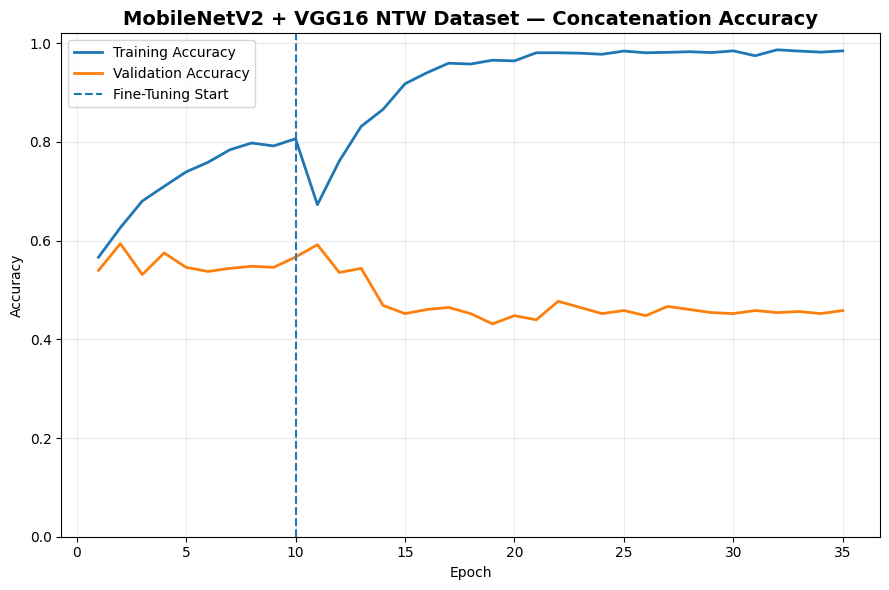

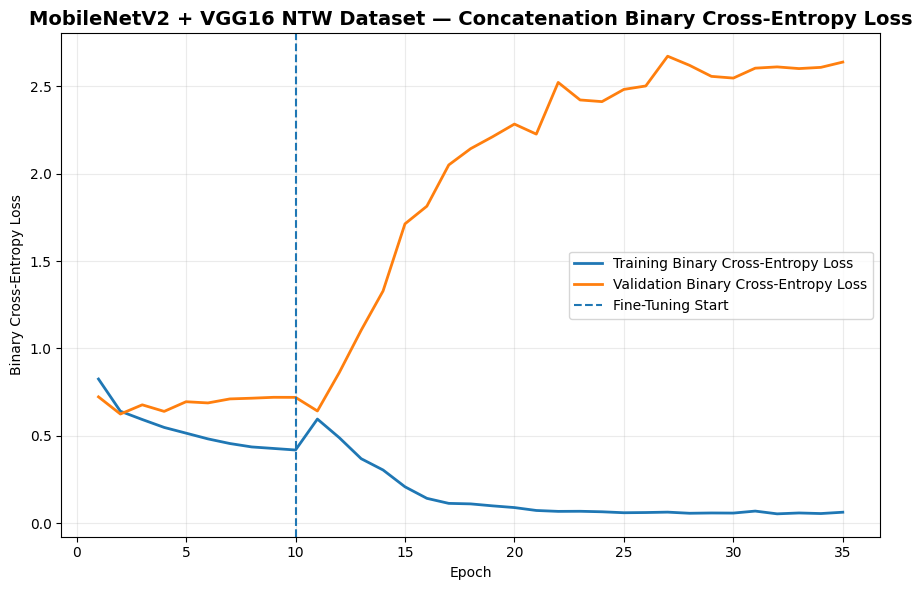

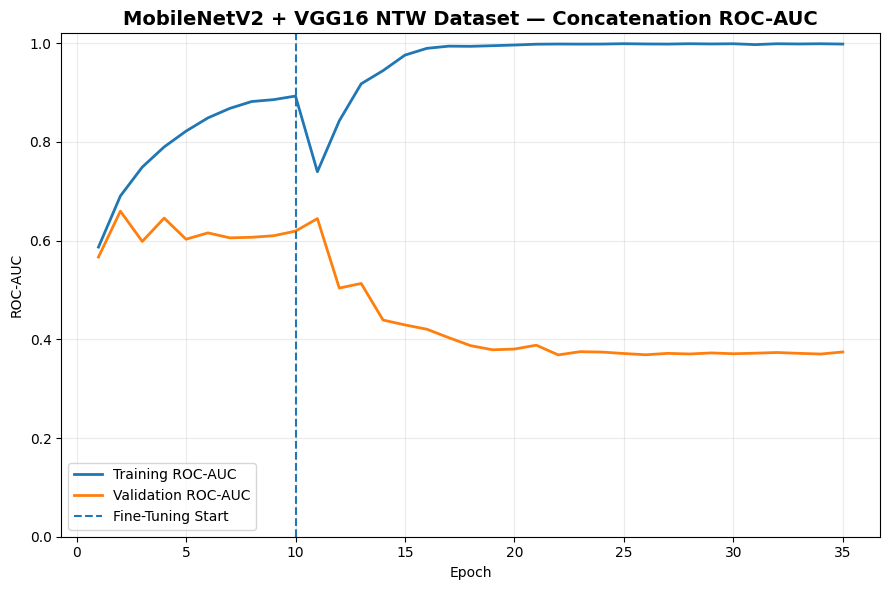

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
Concatenation validation-derived participant threshold: 0.4761
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


,Model,Evaluation_Level,Fusion_Type,Decision_Threshold,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,MobileNetV2_VGG16_concatenation_NTW,Participant-Level,concatenation,0.476131,0.615385,0.625,0.714286,0.5,0.666667,0.666667,3,3,2,5,13


                 precision    recall  f1-score   support

Healthy Control     0.6000    0.5000    0.5455         6
      Parkinson     0.6250    0.7143    0.6667         7

       accuracy                         0.6154        13
      macro avg     0.6125    0.6071    0.6061        13
   weighted avg     0.6135    0.6154    0.6107        13



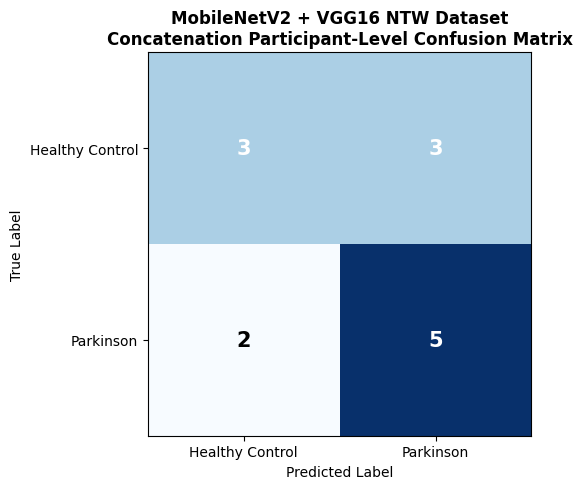

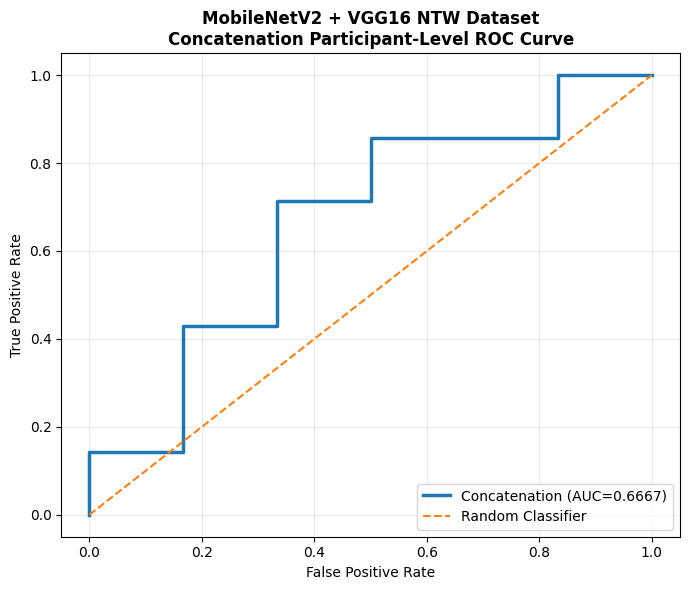

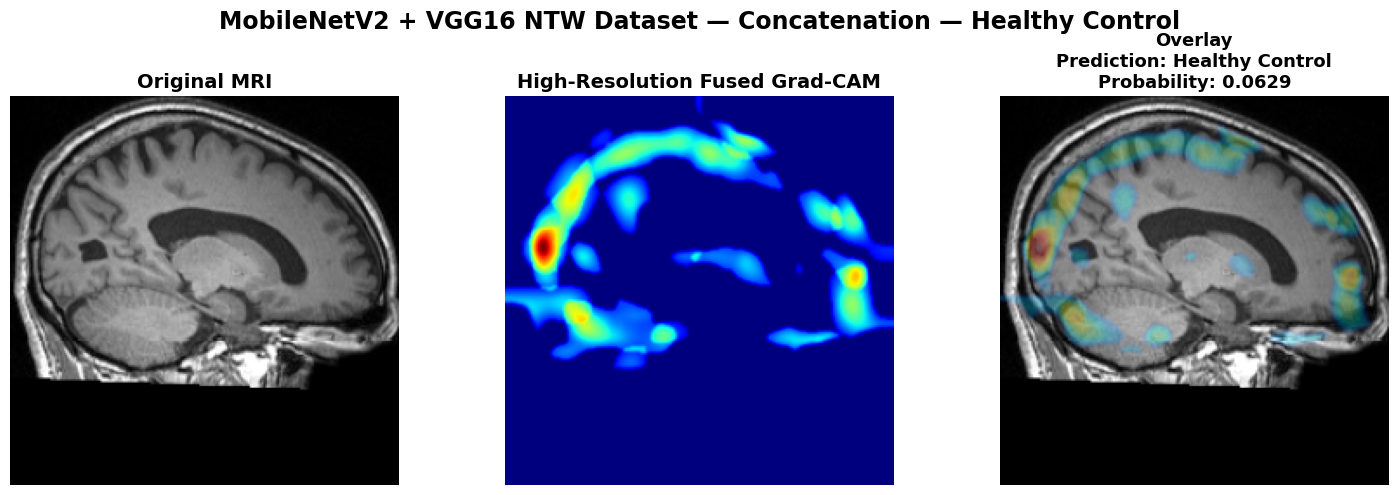

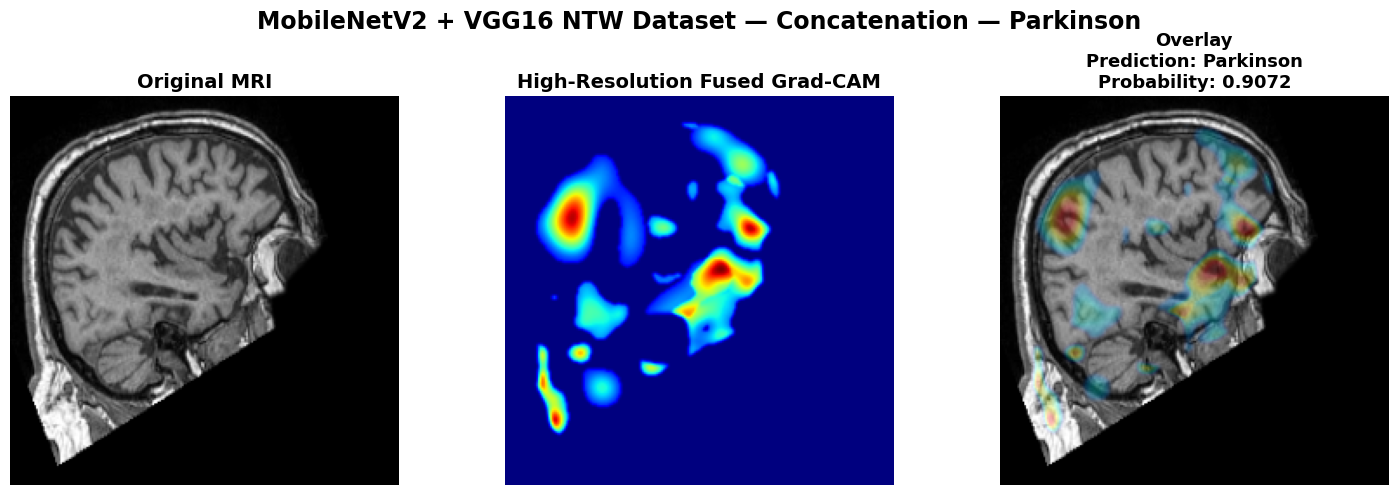

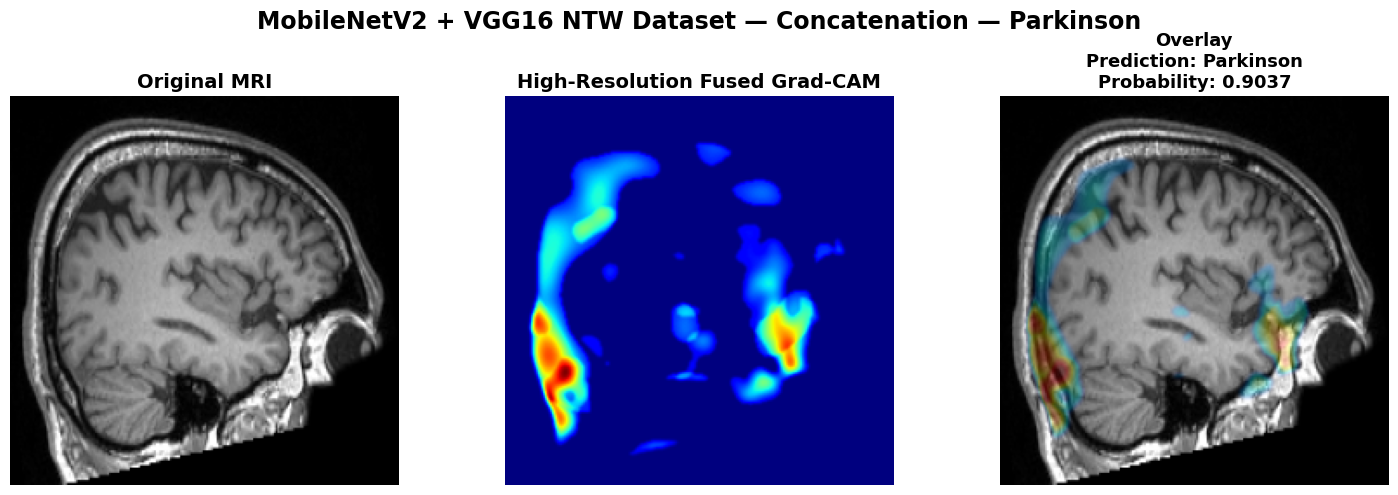

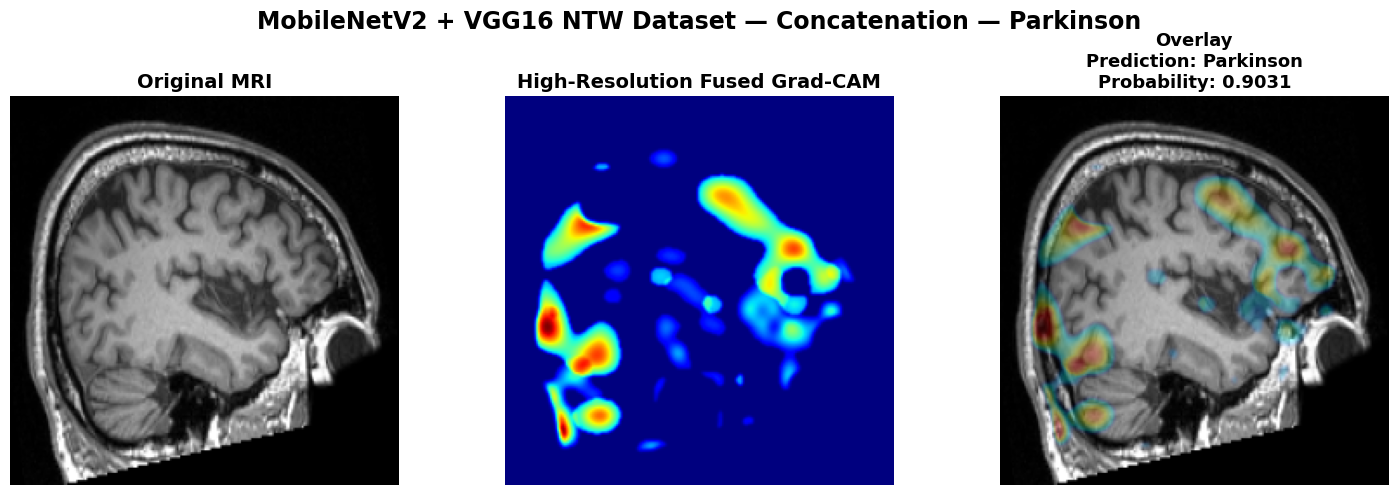

Concatenation accepted Grad-CAM examples: 4


,fusion_type,filepath,patient_id,true_class,probability_parkinson,active_fraction,output_file
0,concatenation,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-control032059,healthy_control,0.063126,0.177637,/content/drive/MyDrive/NTW_dataset_projects_fi...
1,concatenation,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-patient032050,parkinson,0.907672,0.228818,/content/drive/MyDrive/NTW_dataset_projects_fi...
2,concatenation,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-patient032090,parkinson,0.903446,0.138253,/content/drive/MyDrive/NTW_dataset_projects_fi...
3,concatenation,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-patient032090,parkinson,0.902911,0.210980,/content/drive/MyDrive/NTW_dataset_projects_fi...



Training MobileNetV2 + VGG16 Attention Fusion
Epoch 1/10
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5275 - auc: 0.5469 - loss: 0.7261
Epoch 1: val_auc improved from None to 0.59182, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/attention/models/MobileNetV2_VGG16_attention_NTW_warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/attention/models/MobileNetV2_VGG16_attention_NTW_warmup_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.5750 - auc: 0.5994 - loss: 0.6865 - val_accuracy: 0.5417 - val_auc: 0.5918 - val_loss: 0.6597 - learning_rate: 1.0000e-04
Epoch 2/10
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6380 - auc: 0

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,MobileNetV2_VGG16_attention_NTW,17563778,14932226,2631552


Epoch 11/35
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6210 - auc: 0.6778 - loss: 0.6607
Epoch 11: val_auc improved from None to 0.63395, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/attention/models/MobileNetV2_VGG16_attention_NTW_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results/attention/models/MobileNetV2_VGG16_attention_NTW_best.keras
290/290 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.6487 - auc: 0.7110 - loss: 0.6271 - val_accuracy: 0.5833 - val_auc: 0.6339 - val_loss: 0.6808 - learning_rate: 5.0000e-06
Epoch 12/35
289/290 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6981 - auc: 0.7679 - loss: 0.5777
Epoch 12: val_auc did not improve fr

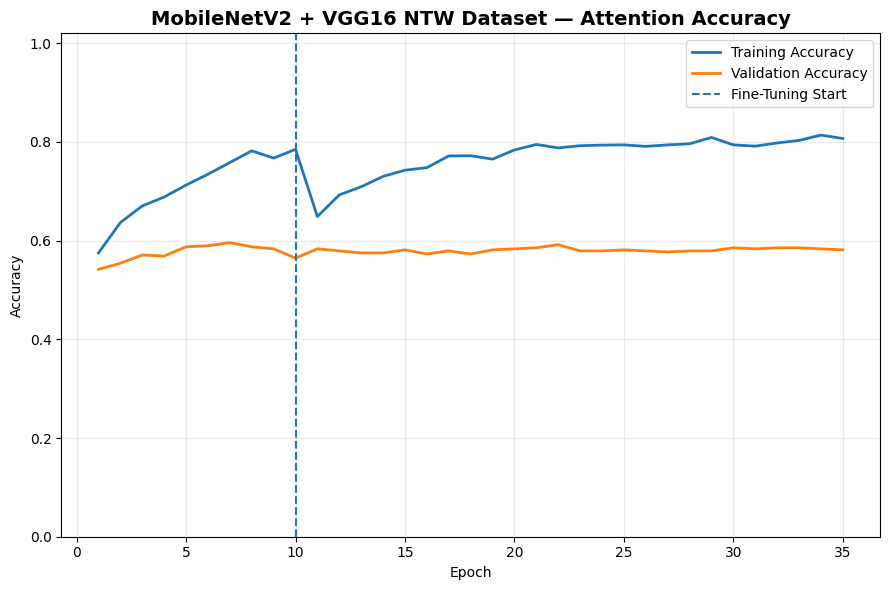

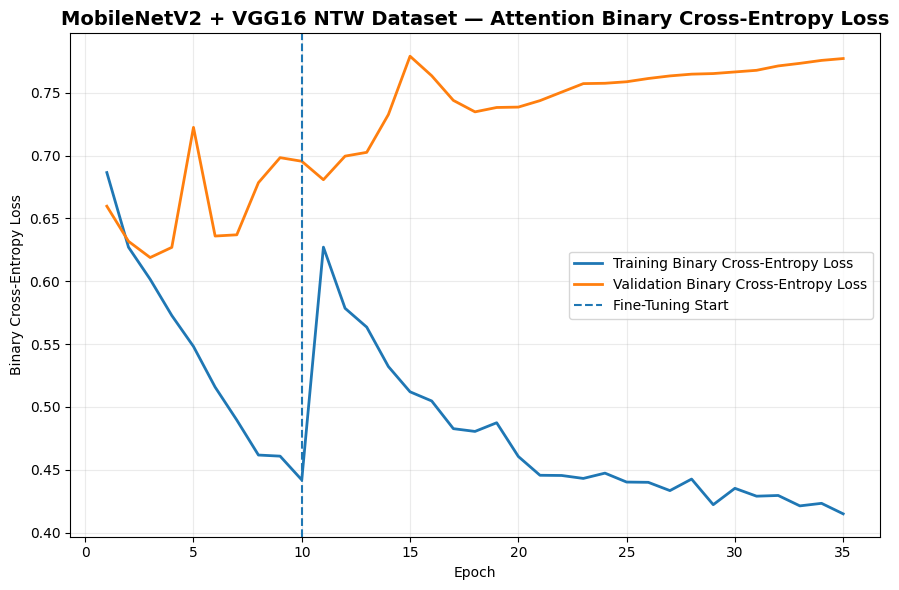

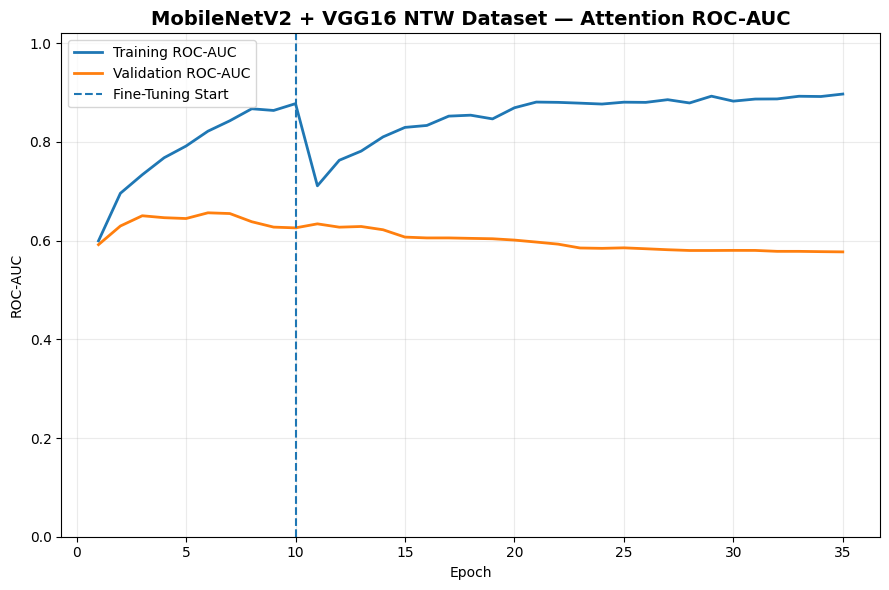

60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
Attention validation-derived participant threshold: 0.8628
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


,Model,Evaluation_Level,Fusion_Type,Decision_Threshold,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,MobileNetV2_VGG16_attention_NTW,Participant-Level,attention,0.862845,0.615385,1.0,0.285714,1.0,0.444444,0.47619,6,0,5,2,13


                 precision    recall  f1-score   support

Healthy Control     0.5455    1.0000    0.7059         6
      Parkinson     1.0000    0.2857    0.4444         7

       accuracy                         0.6154        13
      macro avg     0.7727    0.6429    0.5752        13
   weighted avg     0.7902    0.6154    0.5651        13



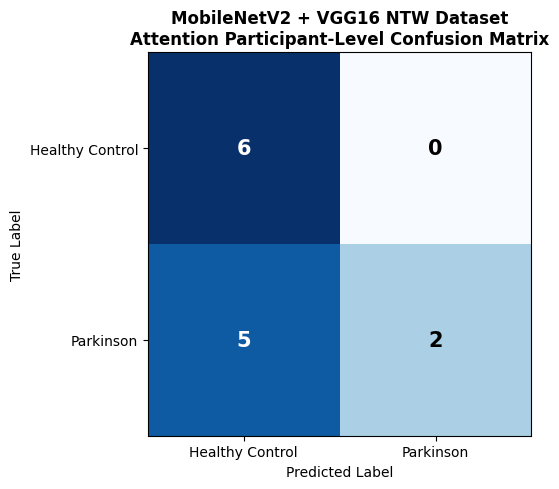

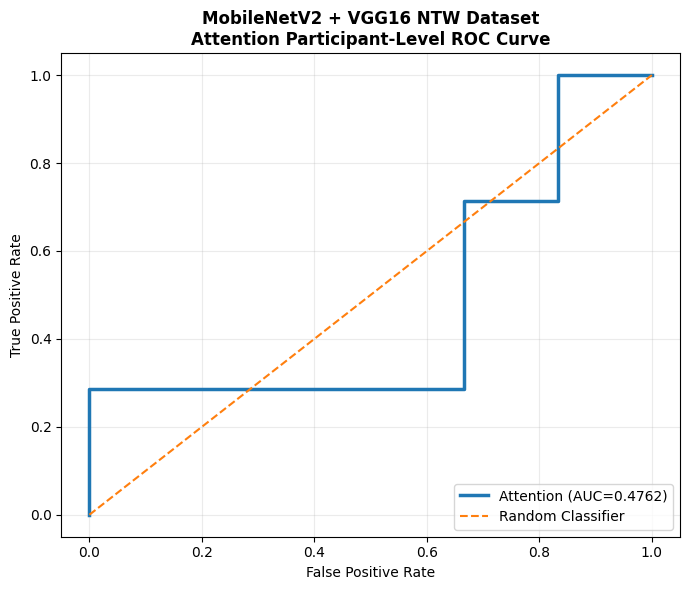

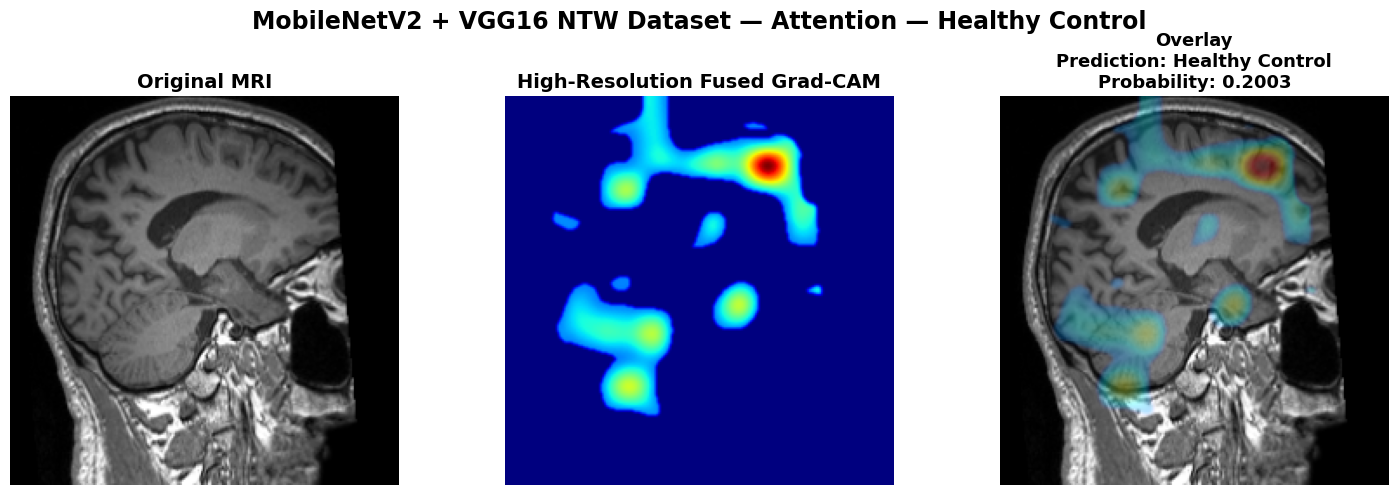

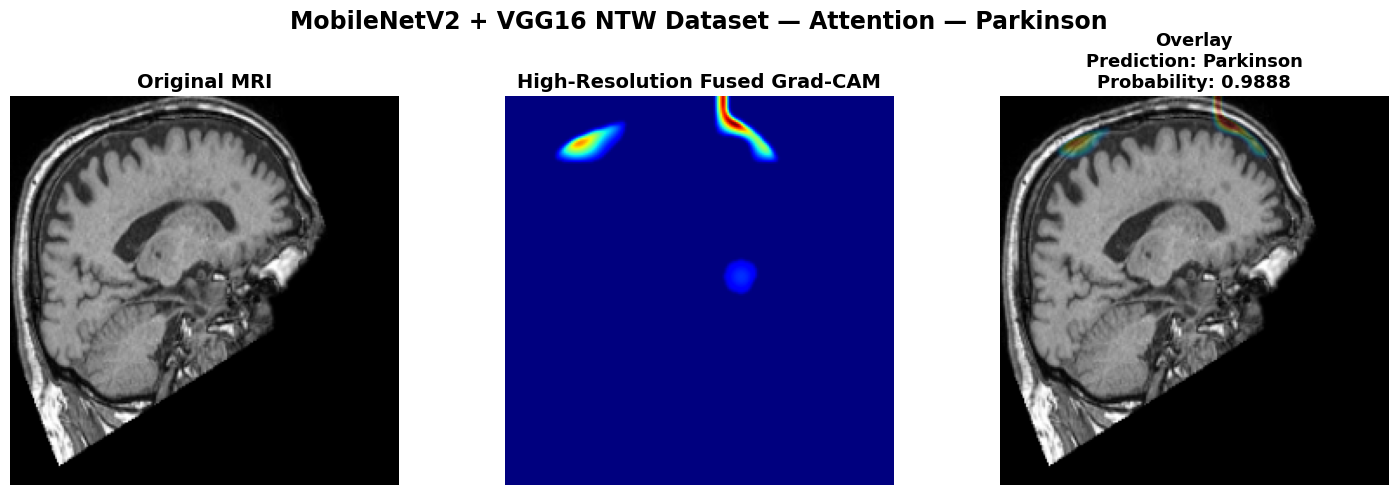

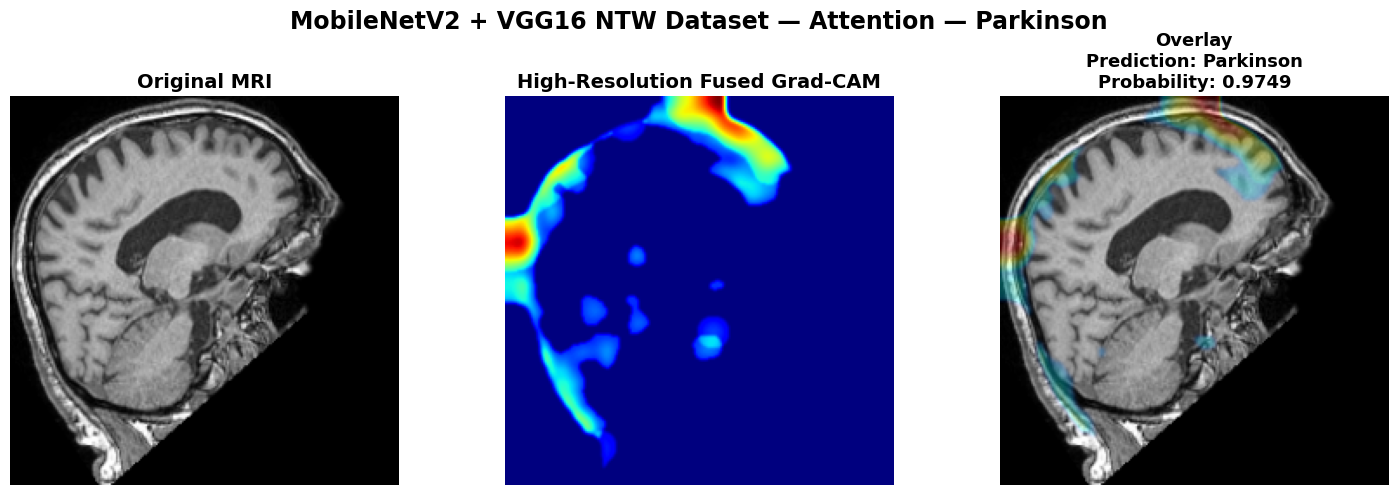

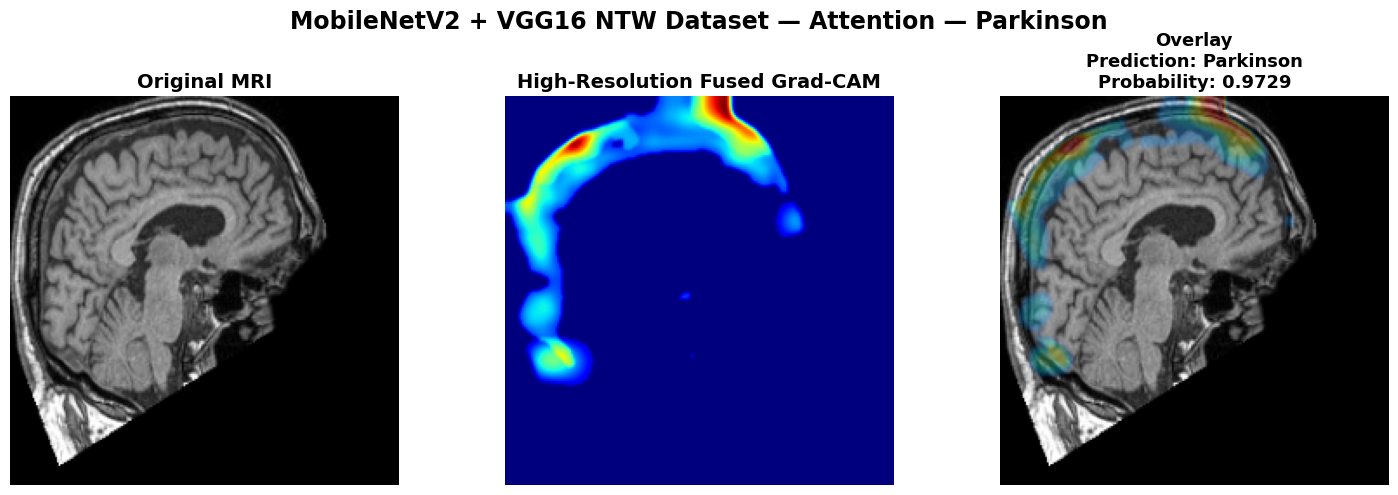

Attention accepted Grad-CAM examples: 4


,fusion_type,filepath,patient_id,true_class,probability_parkinson,active_fraction,output_file
0,attention,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-control032063,healthy_control,0.202122,0.183148,/content/drive/MyDrive/NTW_dataset_projects_fi...
1,attention,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-patient032050,parkinson,0.988486,0.023966,/content/drive/MyDrive/NTW_dataset_projects_fi...
2,attention,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-patient032032,parkinson,0.974695,0.156458,/content/drive/MyDrive/NTW_dataset_projects_fi...
3,attention,/content/drive/MyDrive/NTW_dataset_projects_fi...,sub-patient032050,parkinson,0.973746,0.151640,/content/drive/MyDrive/NTW_dataset_projects_fi...


,Model,Evaluation_Level,Fusion_Type,Decision_Threshold,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,MobileNetV2_VGG16_concatenation_NTW,Participant-Level,concatenation,0.476131,0.615385,0.625,0.714286,0.5,0.666667,0.666667,3,3,2,5,13
1,MobileNetV2_VGG16_attention_NTW,Participant-Level,attention,0.862845,0.615385,1.000,0.285714,1.0,0.444444,0.476190,6,0,5,2,13


Completed. Results saved in: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_patient_level/Mobilenet_vgg16_model_here/Mobilenet_vgg16_corrected_results


In [12]:
# RUN BOTH FUSION METHODS
all_metrics = []

for fusion_type in FUSION_METHODS:
    print("\n" + "=" * 80)
    print(
        "Training MobileNetV2 + VGG16 "
        f"{fusion_type.title()} Fusion"
    )
    print("=" * 80)

    trained_model, run_folders, file_prefix = (
        train_fusion_method(fusion_type)
    )

    method_metrics = evaluate_model(
        trained_model,
        fusion_type,
        run_folders,
        file_prefix,
    )

    all_metrics.append(method_metrics)

    # Free GPU memory before the next model
    del trained_model
    tf.keras.backend.clear_session()

comparison_frame = pd.DataFrame(all_metrics)
display(comparison_frame)

comparison_frame.to_csv(
    Path(SAVE_DIR)
    / "MobileNetV2_VGG16_Participant_Level_Concatenation_vs_Attention_Corrected.csv",
    index=False,
)

print("Completed. Results saved in:", SAVE_DIR)